In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def LIF(mem, w, x, beta, threshold):
    spk = (mem > threshold)

    spk = spk.astype(float)

    mem = beta*mem + w*x - spk*threshold

    return mem, spk

In [11]:
def ALIF(mem, thr, w, x, beta_mem, beta_thr, thr_base, thr_inc):
    
    spk = (mem > thr)
    spk = spk.astype(float)
    
    mem = beta_mem * mem + w * x - spk * thr
    
    thr = beta_thr * (thr - thr_base) + thr_base + spk * thr_inc
    
    return mem, spk, thr

In [12]:
# define all the constants

delta_t = np.array(1e-3)
tau = np.array(5e-3) 
mem_beta = np.exp(-delta_t/tau) # = 0.8187

thr = np.array(1.0)
th_beta = np.array(0.99)
th_base = np.array(1.0)
th_inc = np.array(0.1)

w = 0.4

print(f"The decay rate is: {mem_beta:.3f}")
print(f"The threshold beta is: {th_beta:.3f}")

The decay rate is: 0.819
The threshold beta is: 0.990


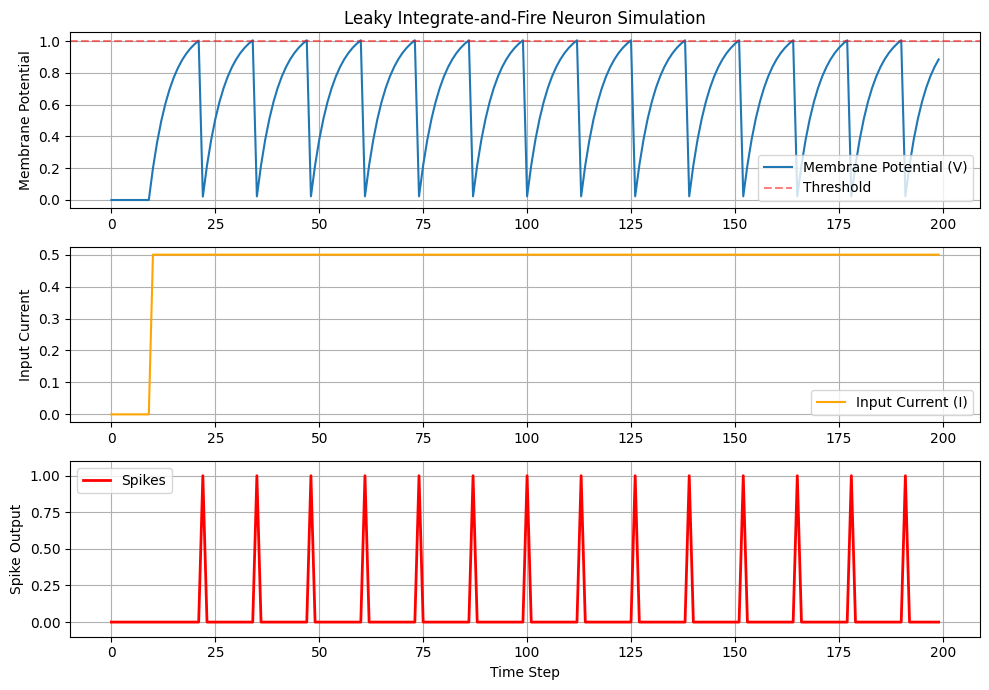

In [13]:
num_steps = 200


# initialize inputs/outputs + small step current input
# replace this line with a numpy version
x = np.concatenate((np.zeros(10), np.ones(190)*0.5))


mem = np.zeros(1)
spk = np.zeros(1)
mem_rec = []
spk_rec = []

# neuron simulation
for step in range(num_steps):
  mem, spk = LIF(mem=mem, x=x[step], w=w, beta=mem_beta, threshold=thr) 
  mem_rec.append(mem)
  spk_rec.append(spk)

# convert lists to tensors
mem_rec = np.array(mem_rec)
spk_rec = np.array(spk_rec)


# Create time axis based on num_steps
time = range(num_steps)

# plot V, I, and spikes
plt.figure(figsize=(10, 7))

plt.subplot(3, 1, 1)
plt.plot(time, mem_rec, label='Membrane Potential (V)')
plt.axhline(y=thr, color='r', linestyle='--', alpha=0.5, label='Threshold')
plt.title('Leaky Integrate-and-Fire Neuron Simulation')
plt.ylabel('Membrane Potential')
plt.legend()
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(time, x, label='Input Current (I)', color='orange')
plt.ylabel('Input Current')
plt.legend()
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(time, spk_rec, 'r', linewidth=2, label='Spikes')
plt.ylabel('Spike Output')
plt.xlabel('Time Step')
plt.ylim([-0.1, 1.1])
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


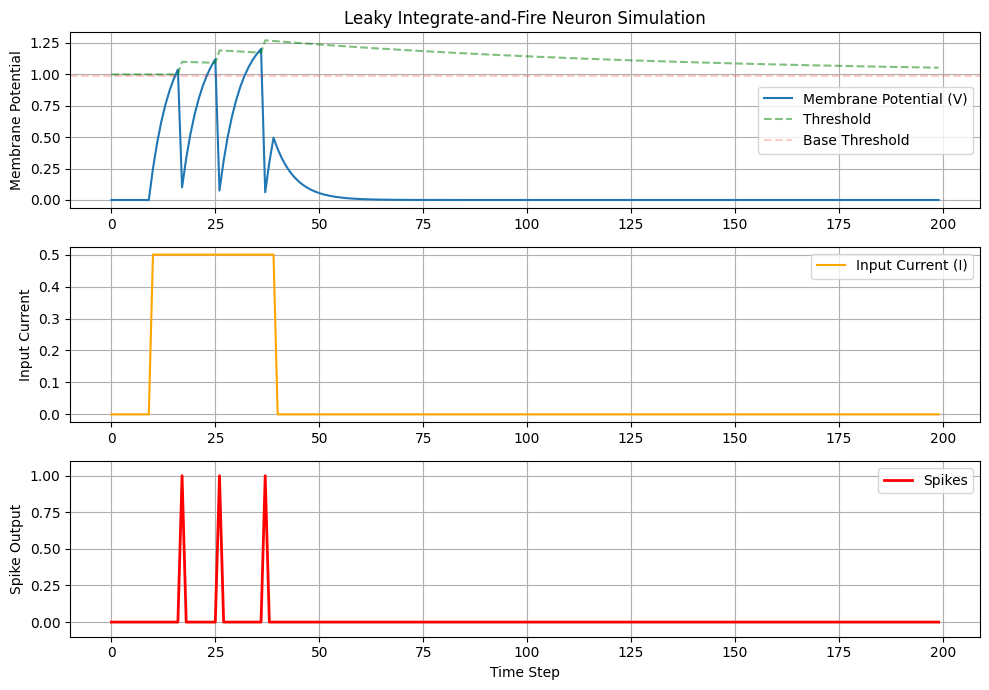

In [163]:
num_steps = 200


# initialize inputs/outputs + small step current input
# replace this line with a numpy version
x = np.concatenate((np.zeros(10), np.ones(30)*0.5, np.zeros(160)))


mem = np.zeros(1)
spk = np.zeros(1)
thr = np.ones(1)
mem_rec = []
spk_rec = []
thr_rec = []

# neuron simulation
for step in range(num_steps):
  mem, spk, thr = ALIF(mem=mem, thr=thr, x=x[step], w=w, beta_mem=mem_beta, beta_thr=th_beta, thr_base=th_base, thr_inc=th_inc)
  thr_rec.append(thr)
  mem_rec.append(mem)
  spk_rec.append(spk)

# convert lists to tensors
mem_rec = np.array(mem_rec)
spk_rec = np.array(spk_rec)
thr_rec = np.array(thr_rec)


# Create time axis based on num_steps
time = range(num_steps)

# plot V, I, and spikes
plt.figure(figsize=(10, 7))

plt.subplot(3, 1, 1)
plt.plot(time, mem_rec, label='Membrane Potential (V)')
plt.plot(time, thr_rec, label='Threshold', color='green', linestyle='--', alpha=0.5) 
plt.axhline(y=th_beta, color='r', linestyle='--', alpha=0.2, label='Base Threshold')
plt.title('Leaky Integrate-and-Fire Neuron Simulation')
plt.ylabel('Membrane Potential')
plt.legend()
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(time, x, label='Input Current (I)', color='orange')
plt.ylabel('Input Current')
plt.legend()
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(time, spk_rec, 'r', linewidth=2, label='Spikes')
plt.ylabel('Spike Output')
plt.xlabel('Time Step')
plt.ylim([-0.1, 1.1])
plt.legend()
plt.grid()



plt.tight_layout()
plt.show()
